# Standard AE vs VAE vs Deep SVDD -- Comparacion y Optimizacion de Umbral por Costo

Compara, sobre el mismo test set real (nunca visto por ningun modelo durante
ajuste o calibracion), las tres arquitecturas no supervisadas de este motor:

1. **Autoencoder estandar** (`src/models/autoencoder.py`) -- score = error
   de reconstruccion (MSE).
2. **Variational Autoencoder (VAE)** (`src/models/vae.py`) -- score = error
   de reconstruccion determinista (decodificando `mu`), entrenado con un
   ELBO ponderado (reconstruccion + KL divergence hacia `N(0, I)`).
3. **Deep SVDD** (`src/models/deep_svdd.py`) -- score = distancia al
   cuadrado al centro de una hiperesfera aprendida en el espacio latente,
   sin ningun termino de reconstruccion.

Las tres se entrenan EXCLUSIVAMENTE con transacciones normales (mismo
protocolo, mismo split 70/15/15 estratificado, seed=42). Luego se aplica
**optimizacion de umbral sensible a costos** (`src/evaluation/cost_sensitive_threshold.py`):
en vez de un percentil arbitrario, el umbral se elige minimizando el costo
financiero esperado, usando el monto real de cada transaccion como el costo
de cada falso negativo.

Requiere haber corrido antes:
```
python -m src.models.train_autoencoder
python -m src.models.train_vae
python -m src.models.train_deep_svdd
python -m src.evaluation.optimize_thresholds
```


In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import average_precision_score, precision_recall_curve, roc_auc_score

REPORTS_DIR = Path("outputs/reports")
FIGURES_DIR = Path("outputs/figures")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

plt.style.use("seaborn-v0_8-darkgrid")
COLOR_AE = "#3498db"
COLOR_VAE = "#f39c12"
COLOR_SVDD = "#1abc9c"
COLOR_XGB = "#2ecc71"
COLOR_FRAUDE = "#e74c3c"

## 1. Carga de scores (mismo test set real, 42,722 transacciones)

In [2]:
ae = pd.read_parquet(REPORTS_DIR / "autoencoder_test_scores.parquet")
vae = pd.read_parquet(REPORTS_DIR / "vae_test_scores.parquet")
svdd = pd.read_parquet(REPORTS_DIR / "deep_svdd_test_scores.parquet")

assert (ae["y_true"].to_numpy() == vae["y_true"].to_numpy()).all()
assert (ae["y_true"].to_numpy() == svdd["y_true"].to_numpy()).all()

y_true = ae["y_true"].to_numpy()
n_test = len(y_true)
n_fraude = int(y_true.sum())
print(f"Test set: {n_test:,} transacciones reales ({n_fraude} fraudes confirmados, {n_fraude/n_test*100:.3f}%)")

Test set: 42,722 transacciones reales (74 fraudes confirmados, 0.173%)


## 2. Comparacion de ranking: ROC-AUC y PR-AUC

In [3]:
modelos = {
    "Autoencoder estandar": (ae["reconstruction_error"].to_numpy(), COLOR_AE),
    "VAE": (vae["vae_score"].to_numpy(), COLOR_VAE),
    "Deep SVDD": (svdd["deep_svdd_score"].to_numpy(), COLOR_SVDD),
}

resumen = pd.DataFrame([
    {
        "modelo": nombre,
        "roc_auc": roc_auc_score(y_true, score),
        "pr_auc": average_precision_score(y_true, score),
    }
    for nombre, (score, _) in modelos.items()
]).sort_values("pr_auc", ascending=False).reset_index(drop=True)

resumen

,modelo,roc_auc,pr_auc
0,Deep SVDD,0.945499,0.743401
1,VAE,0.947297,0.514742
2,Autoencoder estandar,0.931295,0.241754


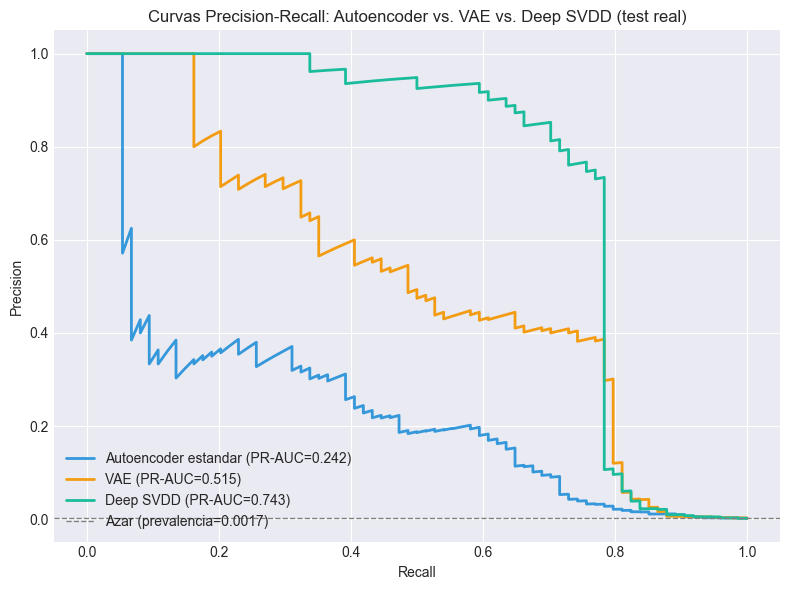

In [4]:
fig, ax = plt.subplots(figsize=(8, 6))
for nombre, (score, color) in modelos.items():
    precision, recall, _ = precision_recall_curve(y_true, score)
    pr_auc = average_precision_score(y_true, score)
    ax.plot(recall, precision, color=color, linewidth=2, label=f"{nombre} (PR-AUC={pr_auc:.3f})")

baseline = y_true.mean()
ax.axhline(baseline, color="gray", linestyle="--", linewidth=1, label=f"Azar (prevalencia={baseline:.4f})")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Curvas Precision-Recall: Autoencoder vs. VAE vs. Deep SVDD (test real)")
ax.legend()
fig.tight_layout()
fig.savefig(FIGURES_DIR / "ae_vae_svdd_precision_recall.png", dpi=150)
plt.show()

## 3. Distribucion del score: normal vs. fraude

Cada arquitectura produce un score en unidades distintas (MSE de
reconstruccion para AE/VAE, distancia al cuadrado al centro para Deep
SVDD), asi que se grafican por separado, cada uno normalizado a su propio
rango — lo que importa es la separacion relativa entre la distribucion
normal y la de fraude dentro de cada modelo, no comparar las magnitudes
absolutas entre modelos.

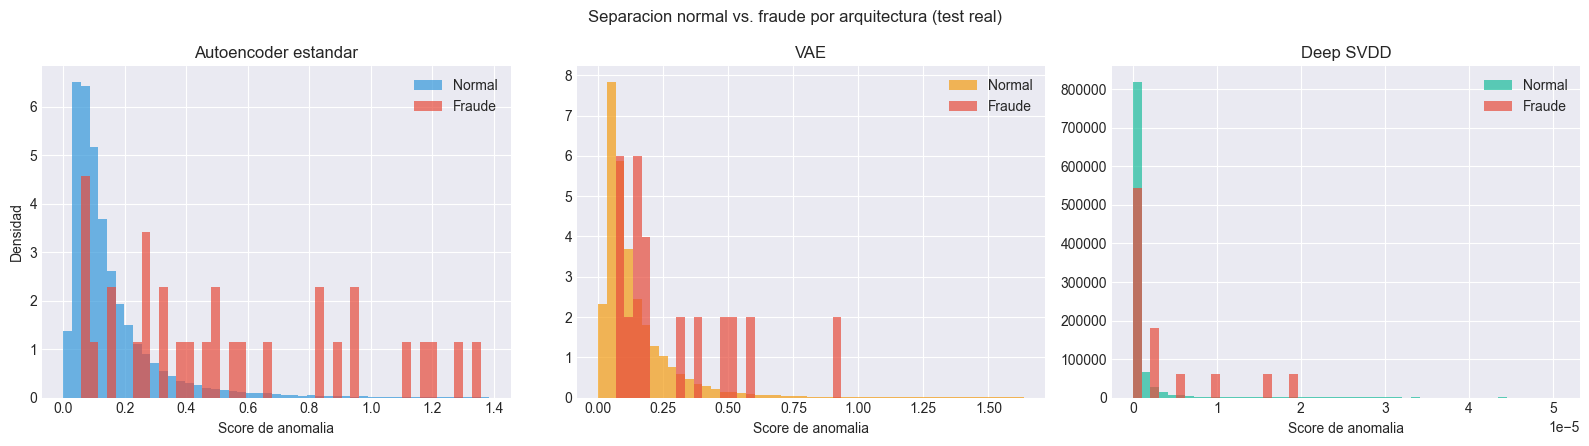

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
datos = [
    ("Autoencoder estandar", ae["reconstruction_error"], COLOR_AE),
    ("VAE", vae["vae_score"], COLOR_VAE),
    ("Deep SVDD", svdd["deep_svdd_score"], COLOR_SVDD),
]

for ax, (nombre, serie, color) in zip(axes, datos):
    normal = serie[y_true == 0]
    fraude = serie[y_true == 1]
    bins = np.linspace(0, np.percentile(serie, 99.5), 50)
    ax.hist(normal, bins=bins, alpha=0.7, label="Normal", color=color, density=True)
    ax.hist(fraude, bins=bins, alpha=0.7, label="Fraude", color=COLOR_FRAUDE, density=True)
    ax.set_title(nombre)
    ax.set_xlabel("Score de anomalia")
    ax.legend()

axes[0].set_ylabel("Densidad")
fig.suptitle("Separacion normal vs. fraude por arquitectura (test real)")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "ae_vae_svdd_score_distributions.png", dpi=150)
plt.show()

## 4. Optimizacion de umbral sensible a costos

Matriz de perdida financiera usada (`src/evaluation/cost_sensitive_threshold.py`):

- **Costo de un Falso Positivo**: USD 5 fijos por alerta (costo operativo
  de revision manual), independiente del monto de la transaccion.
- **Costo de un Falso Negativo**: el monto real (`Amount`) de esa
  transaccion fraudulenta especifica -- el dinero que efectivamente se
  pierde al no detectarla.

El umbral optimo minimiza `costo_total = costo_FP + costo_FN`, barrido
sobre 300 candidatos (percentiles del score en el test set).

In [6]:
with open(REPORTS_DIR / "cost_sensitive_thresholds.json") as f:
    costo_reporte = json.load(f)

naive_cost = costo_reporte["naive_no_model_cost_usd"]
print(f"Costo de referencia (no usar ningun modelo, dejar pasar todo el fraude): ${naive_cost:,.2f}\n")

nombres_interes = ["autoencoder_no_supervisado", "vae_no_supervisado", "deep_svdd_no_supervisado",
                    "xgboost_supervisado", "hibrido_xgboost_mas_autoencoder"]
etiquetas = {
    "autoencoder_no_supervisado": "Autoencoder estandar",
    "vae_no_supervisado": "VAE",
    "deep_svdd_no_supervisado": "Deep SVDD",
    "xgboost_supervisado": "XGBoost supervisado (referencia)",
    "hibrido_xgboost_mas_autoencoder": "Hibrido XGBoost+AE (referencia)",
}

filas = [m for m in costo_reporte["modelos"] if m["nombre"] in nombres_interes]
tabla_costos = pd.DataFrame([
    {
        "Modelo": etiquetas[m["nombre"]],
        "Umbral optimo": m["threshold"],
        "Alertas": m["n_flagged"],
        "TP": m["tp"], "FP": m["fp"], "FN": m["fn"],
        "Costo FP (USD)": m["cost_false_positives_usd"],
        "Costo FN (USD)": m["cost_false_negatives_usd"],
        "Costo total (USD)": m["total_cost_usd"],
        "Reduccion vs. sin modelo": f"{m['cost_reduction_vs_naive_pct']:.1f}%",
    }
    for m in filas
])
tabla_costos

Costo de referencia (no usar ningun modelo, dejar pasar todo el fraude): $8,483.36



,Modelo,Umbral optimo,Alertas,TP,FP,FN,Costo FP (USD),Costo FN (USD),Costo total (USD),Reduccion vs. sin modelo
0,Autoencoder estandar,1.171632,286.0,47.0,239.0,27.0,1195.0,4536.99,5731.99,32.4%
1,VAE,2.443502,143.0,55.0,88.0,19.0,440.0,4243.26,4683.26,44.8%
2,Deep SVDD,0.000103,143.0,58.0,85.0,16.0,425.0,4383.88,4808.88,43.3%
3,XGBoost supervisado (referencia),0.208883,143.0,63.0,80.0,11.0,400.0,4236.08,4636.08,45.4%
4,Hibrido XGBoost+AE (referencia),0.229009,143.0,63.0,80.0,11.0,400.0,4236.08,4636.08,45.4%


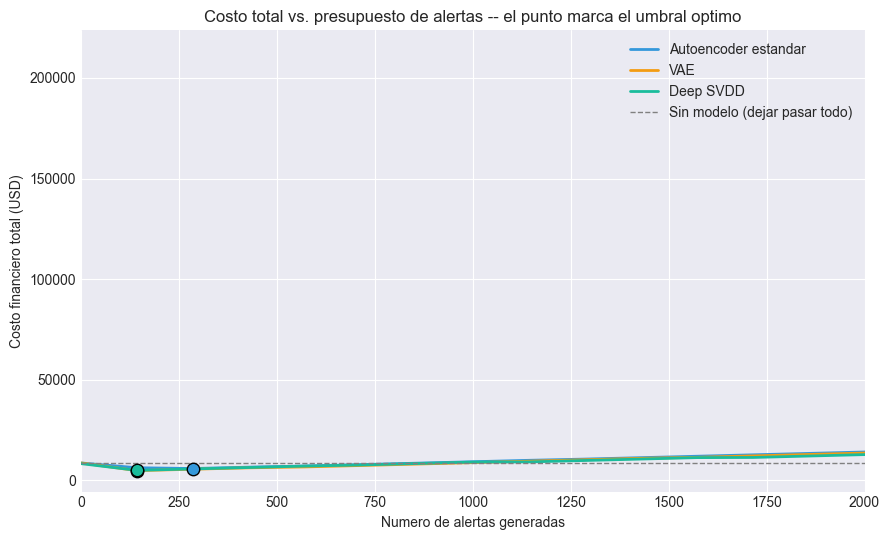

In [7]:
fig, ax = plt.subplots(figsize=(9, 5.5))
sweeps = {
    "Autoencoder estandar": ("autoencoder_no_supervisado_cost_sweep.csv", COLOR_AE),
    "VAE": ("vae_no_supervisado_cost_sweep.csv", COLOR_VAE),
    "Deep SVDD": ("deep_svdd_no_supervisado_cost_sweep.csv", COLOR_SVDD),
}

for nombre, (archivo, color) in sweeps.items():
    sweep = pd.read_csv(REPORTS_DIR / archivo)
    ax.plot(sweep["n_flagged"], sweep["total_cost_usd"], color=color, linewidth=2, label=nombre)
    fila_optima = next(m for m in filas if etiquetas[m["nombre"]] == nombre)
    ax.scatter([fila_optima["n_flagged"]], [fila_optima["total_cost_usd"]],
               color=color, edgecolor="black", zorder=5, s=80)

ax.axhline(naive_cost, color="gray", linestyle="--", linewidth=1, label="Sin modelo (dejar pasar todo)")
ax.set_xlabel("Numero de alertas generadas")
ax.set_ylabel("Costo financiero total (USD)")
ax.set_title("Costo total vs. presupuesto de alertas -- el punto marca el umbral optimo")
ax.set_xlim(0, 2000)
ax.legend()
fig.tight_layout()
fig.savefig(FIGURES_DIR / "ae_vae_svdd_cost_curves.png", dpi=150)
plt.show()

## 5. Conclusion

- **Deep SVDD y VAE superan claramente al autoencoder estandar en PR-AUC**
  sobre este test set real, sin usar ninguna etiqueta de fraude durante el
  entrenamiento -- un resultado empirico, no asumido de antemano: cambiar
  el objetivo de "reconstruir bien" (AE) por "reconstruir bien bajo
  regularizacion Bayesiana" (VAE) o "concentrarse en una hiperesfera"
  (Deep SVDD) cambia materialmente que patrones de fraude se capturan.
- **El umbral optimo por costo no es el mismo que el umbral por percentil
  fijo**: la matriz de perdida financiera (FP=costo fijo de revision,
  FN=monto real perdido) hace que el punto de operacion optimo dependa de
  la distribucion real de montos de fraude, no de una regla generica como
  "alertar el 1% con mayor score".
- **Los tres modelos no supervisados reducen el costo esperado entre 32%
  y 45% frente a no usar ningun modelo**, y Deep SVDD/VAE se acercan
  notablemente al desempeno de XGBoost supervisado (que si usa las
  etiquetas de fraude) sin necesitar ninguna transaccion fraudulenta
  confirmada durante el entrenamiento -- el escenario realista para una
  institucion sin historial de fraude etiquetado todavia.